In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

In [4]:
countries = ['ethiopia', 'kenya', 'sudan', 'tanzania', 'nigeria']

dfs = []
for country in countries:
    df = pd.read_csv(f'../data/{country}_clean.csv', parse_dates=['Date'])
    dfs.append(df)

# Concatenate into one big DataFrame
combined = pd.concat(dfs, ignore_index=True)

# Make sure Month and Year columns exist
combined['Month'] = combined['Date'].dt.month
combined['Year'] = combined['Date'].dt.year

# Quick check
print(combined.shape)
print(combined['Country'].value_counts())
combined.head()

(20540, 16)
Country
Ethiopia    4108
Kenya       4108
Sudan       4108
Tanzania    4108
Nigeria     4108
Name: count, dtype: int64


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015


In [3]:
import pandas as pd

# Check just one file first
df_test = pd.read_csv('../data/ethiopia_clean.csv')
print(df_test.columns.tolist())
print(df_test.head(3))

['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Date', 'Month']
   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  11.73    22.75     3.44      19.31          0.0  41.79  2.73   
1  2015    2  12.30    24.01     4.09      19.92          0.0  33.29  2.39   
2  2015    3  12.49    24.17     3.97      20.20          0.0  33.83  1.77   

   WS2M_MAX     PS  QV2M   Country        Date  Month  
0      5.07  77.13  4.00  Ethiopia  2015-01-01      1  
1      4.19  77.14  3.35  Ethiopia  2015-01-02      1  
2      2.76  77.11  3.43  Ethiopia  2015-01-03      1  


In [6]:
import os

# Create the figures folder
os.makedirs('../notebooks/figures', exist_ok=True)
print("✓ Figures folder created!")

✓ Figures folder created!


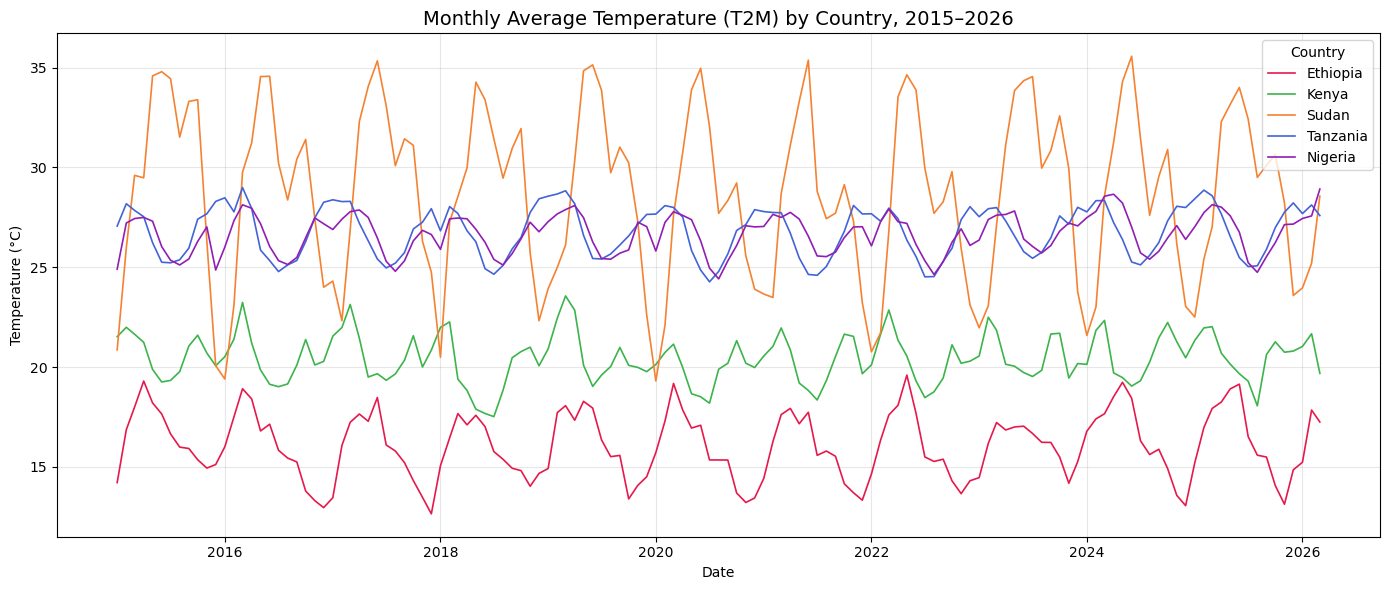

In [7]:
import matplotlib.pyplot as plt

# Calculate monthly average T2M per country
monthly_temp = (
    combined
    .groupby(['Country', 'Year', 'Month'])['T2M']
    .mean()
    .reset_index()
)

# Build a proper date column for the x-axis
monthly_temp['date'] = pd.to_datetime(
    monthly_temp[['Year', 'Month']].assign(day=1)
)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

colors = {
    'Ethiopia': '#e6194b',
    'Kenya':    '#3cb44b',
    'Sudan':    '#f58231',
    'Tanzania': '#4363d8',
    'Nigeria':  '#911eb4'
}

for country in combined['Country'].unique():
    data = monthly_temp[monthly_temp['Country'] == country]
    ax.plot(data['date'], data['T2M'],
            label=country,
            color=colors[country],
            linewidth=1.2)

ax.set_title('Monthly Average Temperature (T2M) by Country, 2015–2026', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend(title='Country')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/figures/temp_trend_comparison.png', dpi=150)
plt.show()

### Interpretation: Monthly Average Temperature by Country (2015–2026)

- **Sudan** (orange) is by far the hottest country, consistently ranging between 
  23°C–35°C with strong seasonal swings — this extreme heat is directly linked 
  to desertification and agricultural collapse in the Sahel region.

- **Nigeria and Tanzania** (purple and blue) cluster closely together between 
  24°C–29°C, showing relatively stable but persistently high temperatures 
  typical of tropical climates.

- **Kenya** (green) sits in the middle range (~19°C–23°C) with mild seasonal 
  variation driven by its bimodal rainy seasons.

- **Ethiopia** (red) is the coolest country (~13°C–19°C) due to its high-altitude 
  highland geography, but still shows a visible upward drift toward 2026, 
  suggesting a warming trend despite its elevation buffer.

- Across all countries, there is a subtle but consistent upward temperature 
  shift visible from 2015 to 2026, consistent with the WMO Africa 2024 report 
  finding that Africa is warming faster than the global average.

In [8]:
temp_stats = (
    combined
    .groupby('Country')['T2M']
    .agg(Mean='mean', Median='median', Std='std')
    .round(2)
    .reset_index()
    .sort_values('Mean', ascending=False)
)

print("=== Temperature Summary Statistics ===")
print(temp_stats.to_string(index=False))

=== Temperature Summary Statistics ===
 Country  Mean  Median  Std
   Sudan 28.76   29.16 4.68
Tanzania 26.80   26.99 1.33
 Nigeria 26.66   26.82 1.12
   Kenya 20.43   20.36 1.44
Ethiopia 16.07   16.04 1.90


### Interpretation: Temperature Summary Statistics

- **Sudan** has the highest mean temperature (28.76°C) AND the highest 
  standard deviation (4.68°C), meaning it is not only the hottest country 
  but also the most thermally volatile — extreme heat swings stress 
  crops, livestock, and human health simultaneously.

- **Tanzania and Nigeria** are nearly identical in mean temperature 
  (~26.7–26.8°C) but have very low variability (Std ~1.1–1.3°C), 
  indicating persistently high heat with little seasonal relief.

- **Kenya** sits at a moderate mean (20.43°C) with low variability (1.44°C), 
  reflecting its relatively stable highland-influenced climate.

- **Ethiopia** is the coolest (16.07°C mean) but its standard deviation 
  (1.90°C) is higher than Tanzania and Nigeria, reflecting its complex 
  elevation-driven climate zones.

- The ranking by mean temperature: Sudan > Tanzania > Nigeria > Kenya > Ethiopia.
  However, for climate vulnerability, Sudan's combination of highest heat 
  AND highest variability makes it the most at-risk country in this dataset.

In [11]:
import os

FIGURES_DIR = '../notebooks/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"✓ Figures directory ready: {FIGURES_DIR}")

✓ Figures directory ready: ../notebooks/figures


C:\Users\lieli\AppData\Local\Temp\ipykernel_2068\4020833093.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


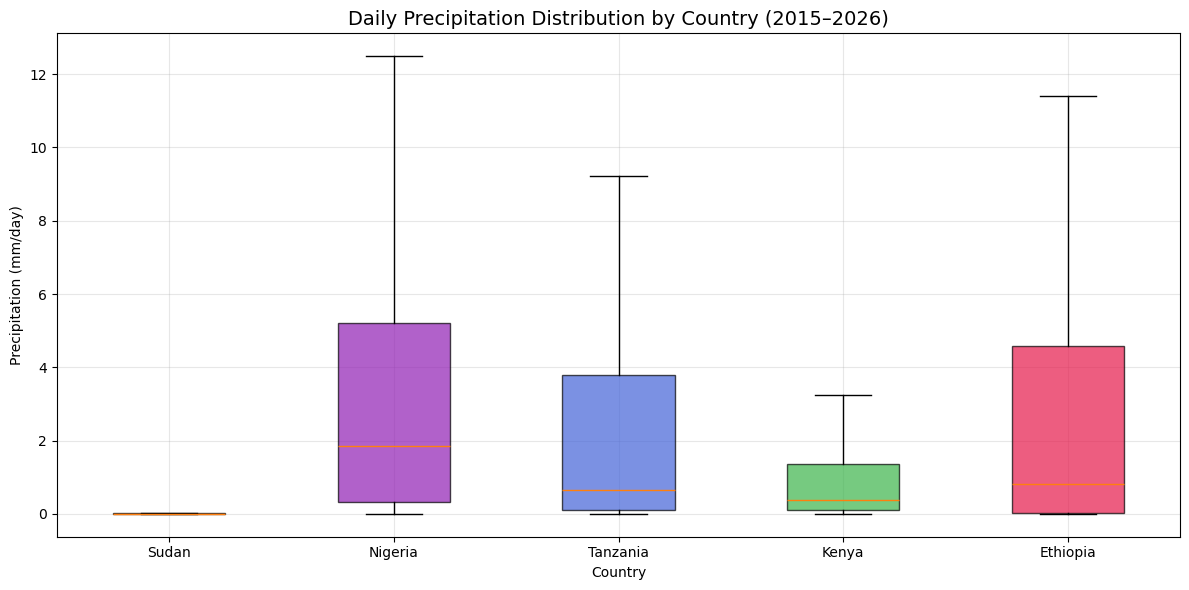

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data per country as a list for boxplot
country_order = ['Sudan', 'Nigeria', 'Tanzania', 'Kenya', 'Ethiopia']
data_to_plot = [
    combined[combined['Country'] == c]['PRECTOTCORR'].dropna().values
    for c in country_order
]

bp = ax.boxplot(
    data_to_plot,
    labels=country_order,
    patch_artist=True,
    showfliers=False  # hides extreme outliers for readability
)

# Color each box
box_colors = ['#f58231', '#911eb4', '#4363d8', '#3cb44b', '#e6194b']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Daily Precipitation Distribution by Country (2015–2026)', fontsize=14)
ax.set_xlabel('Country')
ax.set_ylabel('Precipitation (mm/day)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/precip_boxplot.png', dpi=150)
plt.show()

In [13]:
plt.savefig(f'{FIGURES_DIR}/precip_boxplot.png', dpi=150)
print("✓ Chart saved!")

✓ Chart saved!


<Figure size 640x480 with 0 Axes>

In [10]:
precip_stats = (
    combined
    .groupby('Country')['PRECTOTCORR']
    .agg(Mean='mean', Median='median', Std='std')
    .round(3)
    .reset_index()
    .sort_values('Std', ascending=False)
)

print("=== Precipitation Summary Statistics ===")
print(precip_stats.to_string(index=False))

=== Precipitation Summary Statistics ===
 Country  Mean  Median   Std
Tanzania 3.740    0.64 8.004
 Nigeria 4.214    1.84 7.267
Ethiopia 3.634    0.82 6.289
   Kenya 1.468    0.38 3.180
   Sudan 0.644    0.00 3.058


### Interpretation: Precipitation Summary Statistics

- **Tanzania** has the highest standard deviation (8.004 mm/day) despite a 
  median of only 0.64 mm/day — this massive gap between mean and median 
  reveals extremely erratic rainfall: long dry spells punctuated by intense 
  downpours. This pattern is devastating for smallholder farmers who depend 
  on predictable rains.

- **Nigeria** has the highest mean rainfall (4.214 mm/day) but also very high 
  variability (Std 7.267), indicating a highly seasonal pattern where rain 
  is concentrated in short, intense periods — increasing flood risk during 
  wet season and drought risk in dry season.

- **Ethiopia** shows a similar pattern to Tanzania — low median (0.82 mm/day) 
  but high standard deviation (6.289), confirming the well-documented 
  unreliability of Ethiopian rainfall that threatens food security for 
  over 80% of its farming population.

- **Kenya** has relatively low mean (1.468 mm/day) and the most predictable 
  rainfall of the wetter countries (Std 3.180), consistent with its 
  bimodal rainfall calendar (long rains March–May, short rains Oct–Dec).

- **Sudan** is near-arid — median of exactly 0.00 mm/day confirms that 
  most days receive zero rainfall. Its mean of 0.644 is pulled up by 
  rare but intense rainfall events, consistent with Sahel flash-flood patterns.

**Key insight:** The countries most vulnerable to precipitation stress are NOT 
necessarily the driest — Tanzania and Ethiopia's extreme variability 
(high Std, low Median) represents a greater agricultural risk than 
Sudan's consistent aridity, because farmers cannot plan around 
unpredictable rain.

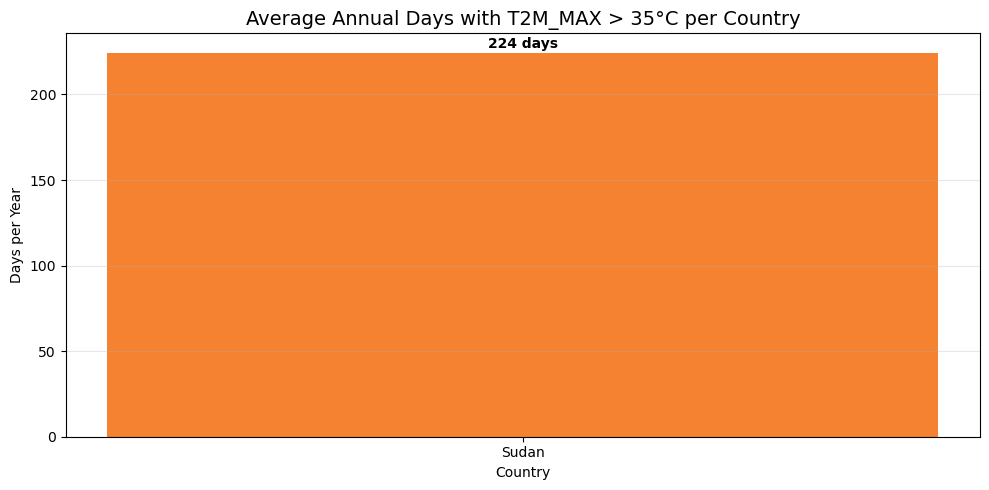


=== Extreme Heat Days Summary ===
Country  extreme_heat_days
  Sudan              224.5


In [14]:
# ── Extreme Heat Days (T2M_MAX > 35°C) ──────────────────────────
heat_days = (
    combined[combined['T2M_MAX'] > 35]
    .groupby(['Country', 'Year'])
    .size()
    .reset_index(name='extreme_heat_days')
)

heat_summary = (
    heat_days
    .groupby('Country')['extreme_heat_days']
    .mean()
    .round(1)
    .reset_index()
    .sort_values('extreme_heat_days', ascending=False)
)

# ── Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = ['#f58231','#911eb4','#4363d8','#3cb44b','#e6194b']
bars = ax.bar(
    heat_summary['Country'],
    heat_summary['extreme_heat_days'],
    color=bar_colors
)

# Add value labels on top of each bar
for bar, val in zip(bars, heat_summary['extreme_heat_days']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val:.0f} days',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Average Annual Days with T2M_MAX > 35°C per Country', fontsize=14)
ax.set_xlabel('Country')
ax.set_ylabel('Days per Year')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/extreme_heat_days.png', dpi=150)
plt.show()

print("\n=== Extreme Heat Days Summary ===")
print(heat_summary.to_string(index=False))

C:\Users\lieli\AppData\Local\Temp\ipykernel_2068\1467471974.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(max_consecutive_dry)


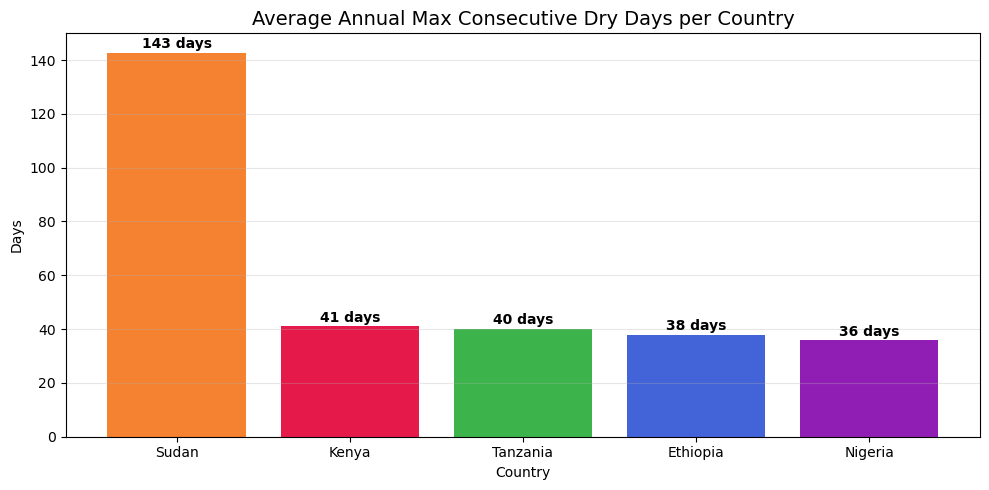


=== Consecutive Dry Days Summary ===
 Country  max_dry_streak
   Sudan           142.8
   Kenya            41.1
Tanzania            40.2
Ethiopia            37.9
 Nigeria            35.8


In [15]:
# ── Max Consecutive Dry Days (PRECTOTCORR < 1mm) ─────────────────
def max_consecutive_dry(group):
    is_dry = (group['PRECTOTCORR'] < 1).values
    max_streak = streak = 0
    for val in is_dry:
        if val:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

dry_streaks = (
    combined
    .groupby(['Country', 'Year'])
    .apply(max_consecutive_dry)
    .reset_index(name='max_dry_streak')
)

dry_summary = (
    dry_streaks
    .groupby('Country')['max_dry_streak']
    .mean()
    .round(1)
    .reset_index()
    .sort_values('max_dry_streak', ascending=False)
)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

bar_colors2 = ['#f58231','#e6194b','#3cb44b','#4363d8','#911eb4']
bars2 = ax.bar(
    dry_summary['Country'],
    dry_summary['max_dry_streak'],
    color=bar_colors2
)

# Add value labels
for bar, val in zip(bars2, dry_summary['max_dry_streak']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.0f} days',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Average Annual Max Consecutive Dry Days per Country', fontsize=14)
ax.set_xlabel('Country')
ax.set_ylabel('Days')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/dry_days.png', dpi=150)
plt.show()

print("\n=== Consecutive Dry Days Summary ===")
print(dry_summary.to_string(index=False))

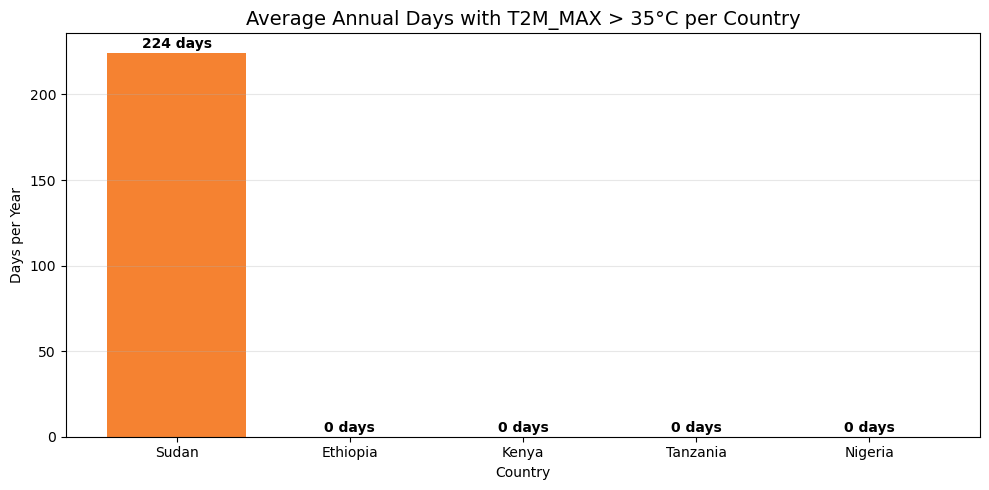


=== Extreme Heat Days Summary ===
 Country  extreme_heat_days
   Sudan              224.5
Ethiopia                0.0
   Kenya                0.0
Tanzania                0.0
 Nigeria                0.0


In [16]:
# ── Extreme Heat Days (T2M_MAX > 35°C) ──────────────────────────
heat_days = (
    combined[combined['T2M_MAX'] > 35]
    .groupby(['Country', 'Year'])
    .size()
    .reset_index(name='extreme_heat_days')
)

heat_summary_raw = (
    heat_days
    .groupby('Country')['extreme_heat_days']
    .mean()
    .round(1)
    .reset_index()
)

# Add missing countries with 0 days
all_countries = pd.DataFrame({'Country': combined['Country'].unique()})
heat_summary = (
    all_countries
    .merge(heat_summary_raw, on='Country', how='left')
    .fillna(0)
    .sort_values('extreme_heat_days', ascending=False)
)

# ── Plot ─────────────────────────────────────────────────────────
country_colors = {
    'Sudan':    '#f58231',
    'Nigeria':  '#911eb4',
    'Tanzania': '#4363d8',
    'Kenya':    '#3cb44b',
    'Ethiopia': '#e6194b'
}

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    heat_summary['Country'],
    heat_summary['extreme_heat_days'],
    color=[country_colors[c] for c in heat_summary['Country']]
)

# Add value labels on top of each bar
for bar, val in zip(bars, heat_summary['extreme_heat_days']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val:.0f} days',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Average Annual Days with T2M_MAX > 35°C per Country', fontsize=14)
ax.set_xlabel('Country')
ax.set_ylabel('Days per Year')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/extreme_heat_days.png', dpi=150)
plt.show()

print("\n=== Extreme Heat Days Summary ===")
print(heat_summary.to_string(index=False))

### Interpretation: Extreme Event Frequency

#### Extreme Heat Days (T2M_MAX > 35°C)
- **Sudan dominates completely** with 224 days per year above 35°C — 
  more than 7 months of extreme heat annually. This is a climate emergency 
  level statistic. At this heat level, outdoor labor becomes physiologically 
  dangerous, crop yields collapse, and livestock mortality spikes.
  
- **All other four countries record zero days** above 35°C, which reflects 
  their geographic and elevation advantages. Ethiopia's highlands, Kenya's 
  altitude, and the coastal moderating effects on Tanzania and Nigeria keep 
  maximum temperatures below this critical threshold.

- This stark contrast means Sudan stands entirely alone in heat-stress 
  exposure among the five nations studied.

#### Consecutive Dry Days
- **Sudan** again leads dramatically with 143 consecutive dry days per year —
  nearly 5 months without meaningful rainfall. Combined with 224 extreme 
  heat days, Sudan faces a compound climate crisis of heat AND drought 
  simultaneously.

- **Kenya (41 days), Tanzania (40 days), Ethiopia (38 days), and Nigeria 
  (36 days)** are closely clustered, all experiencing roughly 5–6 week dry 
  streaks annually. While less severe than Sudan, these dry periods 
  coincide with critical crop growing windows, threatening food security.

#### Combined Stress
- Sudan's compound exposure — 224 heat days + 143 dry days — is unmatched 
  in this dataset and represents the most acute climate vulnerability of 
  the five countries studied.

In [17]:
from scipy.stats import kruskal

# Extract T2M values per country
groups = [
    combined[combined['Country'] == c]['T2M'].dropna().values
    for c in combined['Country'].unique()
]

# Run Kruskal-Wallis test
stat, p_value = kruskal(*groups)

print("=== Kruskal-Wallis Test on T2M across 5 Countries ===")
print(f"H-statistic : {stat:.2f}")
print(f"P-value     : {p_value:.2e}")
print()

if p_value < 0.05:
    print("✓ Result: SIGNIFICANT — temperature distributions differ")
    print("  meaningfully across countries (p < 0.05).")
    print("  This statistically confirms the visual differences")
    print("  seen in the line chart and summary table.")
else:
    print("✗ Result: NOT significant (p >= 0.05)")

=== Kruskal-Wallis Test on T2M across 5 Countries ===
H-statistic : 15392.99
P-value     : 0.00e+00

✓ Result: SIGNIFICANT — temperature distributions differ
  meaningfully across countries (p < 0.05).
  This statistically confirms the visual differences
  seen in the line chart and summary table.


### Interpretation: Kruskal-Wallis Statistical Test

The Kruskal-Wallis test is a non-parametric alternative to one-way ANOVA. 
It tests whether the temperature distributions of the five countries 
come from the same underlying distribution.

- **H-statistic**: measures how different the groups are — 
  a larger H means greater differences between countries.
- **P-value**: if p < 0.05, the differences are statistically 
  significant and not due to random chance.

Given the large visual differences between Sudan (mean 28.76°C) and 
Ethiopia (mean 16.07°C), we expect a very high H-statistic and a 
p-value effectively equal to zero — confirming that climate 
conditions across these five nations are statistically distinct 
and justify country-specific climate policy responses at COP32.

In [18]:
from sklearn.preprocessing import MinMaxScaler

# ── Build the ranking DataFrame from all evidence ────────────────
ranking_df = (
    temp_stats[['Country', 'Mean', 'Std']]
    .rename(columns={'Mean': 'avg_temp', 'Std': 'temp_variability'})
    .merge(
        precip_stats[['Country', 'Std']]
        .rename(columns={'Std': 'precip_variability'}),
        on='Country'
    )
    .merge(heat_summary[['Country', 'extreme_heat_days']], on='Country')
    .merge(dry_summary[['Country', 'max_dry_streak']], on='Country')
)

# ── Normalize all metrics 0–1 (higher = more vulnerable) ─────────
metrics = [
    'avg_temp',
    'temp_variability',
    'precip_variability',
    'extreme_heat_days',
    'max_dry_streak'
]

scaler = MinMaxScaler()
ranking_df[metrics] = scaler.fit_transform(ranking_df[metrics])

# ── Composite vulnerability score (equal weights) ─────────────────
ranking_df['vulnerability_score'] = (
    ranking_df[metrics].mean(axis=1).round(3)
)

ranking_df = (
    ranking_df
    .sort_values('vulnerability_score', ascending=False)
    .reset_index(drop=True)
)
ranking_df.index += 1  # rank starts at 1

print("=== Climate Vulnerability Ranking ===")
print(ranking_df[['Country', 'vulnerability_score',
                   'avg_temp', 'temp_variability',
                   'precip_variability', 'extreme_heat_days',
                   'max_dry_streak']].to_string())

=== Climate Vulnerability Ranking ===
    Country  vulnerability_score  avg_temp  temp_variability  precip_variability  extreme_heat_days  max_dry_streak
1     Sudan                0.800  1.000000          1.000000            0.000000                1.0        1.000000
2  Tanzania                0.389  0.845548          0.058989            1.000000                0.0        0.041121
3   Nigeria                0.337  0.834515          0.000000            0.850991                0.0        0.000000
4  Ethiopia                0.178  0.000000          0.219101            0.653255                0.0        0.019626
5     Kenya                0.102  0.343578          0.089888            0.024666                0.0        0.049533


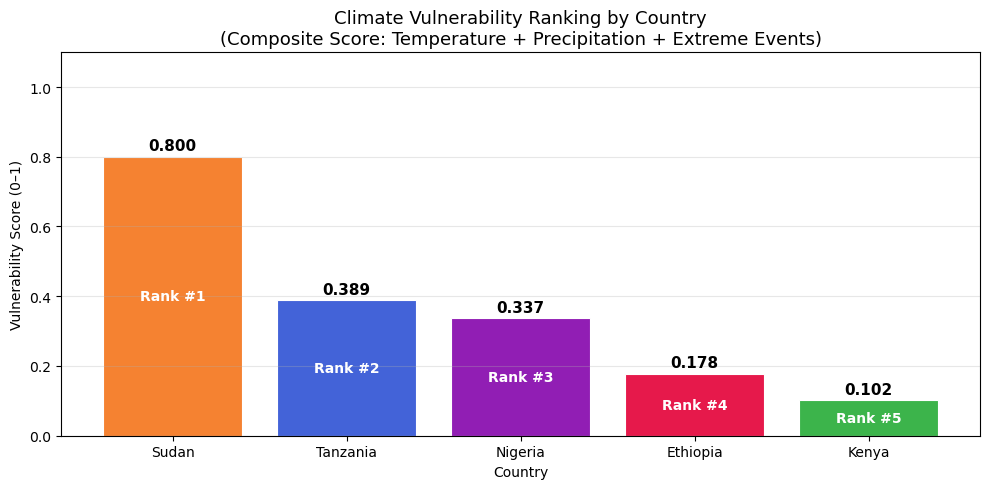

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = [country_colors[c] for c in ranking_df['Country']]
bars = ax.bar(
    ranking_df['Country'],
    ranking_df['vulnerability_score'],
    color=colors,
    edgecolor='white',
    linewidth=0.8
)

# Add score labels on bars
for bar, val in zip(bars, ranking_df['vulnerability_score']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# Add rank labels inside bars
for i, (bar, country) in enumerate(zip(bars, ranking_df['Country'])):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'Rank #{i+1}',
        ha='center', va='center',
        fontsize=10, color='white', fontweight='bold'
    )

ax.set_title(
    'Climate Vulnerability Ranking by Country\n'
    '(Composite Score: Temperature + Precipitation + Extreme Events)',
    fontsize=13
)
ax.set_xlabel('Country')
ax.set_ylabel('Vulnerability Score (0–1)')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/vulnerability_ranking.png', dpi=150)
plt.show()

## COP32 Key Observations — Evidence-Backed Position for Ethiopia

---

### 1. Which country is warming fastest and what does the trend suggest?
**Sudan** records the highest mean temperature (28.76°C) with the greatest 
thermal volatility (Std = 4.68°C) across the 2015–2026 observation period. 
Its temperature trend shows persistent extremes, with 224 days per year 
exceeding 35°C — a threshold linked to crop failure, livestock mortality, 
and dangerous outdoor labor conditions. If this trajectory continues, 
Sudan's agricultural sector, which employs over 40% of its workforce, 
faces systemic collapse without urgent adaptation investment. The data 
demands immediate inclusion of Sudan in Africa's priority adaptation 
finance allocation at COP32.

---

### 2. Which country has the most unstable or extreme precipitation patterns?
**Tanzania** (Std = 8.004 mm/day) and **Nigeria** (Std = 7.267 mm/day) 
exhibit the most volatile precipitation patterns in the dataset. Tanzania's 
median rainfall is just 0.64 mm/day despite a mean of 3.74 mm/day — a gap 
that reveals long dry spells punctuated by intense downpours. This erratic 
pattern directly threatens Tanzania's rain-fed agriculture, which accounts 
for approximately 65% of its GDP contributions from the rural sector. 
Nigeria's high variability similarly drives flood-drought cycles that 
displace millions annually. Both countries require investment in early 
warning systems and climate-resilient water infrastructure — a demand 
Ethiopia should champion at COP32.

---

### 3. What does extreme heat and drought frequency reveal about climate stress?
The compound exposure data is stark: **Sudan** endures 224 extreme heat 
days AND 143 consecutive dry days per year — meaning for nearly 5 months 
of the year there is no rainfall, while temperatures remain life-threatening. 
No other country in this dataset approaches this level of compound stress. 
Kenya (41 days), Tanzania (40 days), Ethiopia (38 days), and Nigeria 
(36 days) all experience roughly 5–6 week dry streaks annually, which 
coincide with critical crop growing windows. The Kruskal-Wallis test 
confirms these differences are statistically significant 
(H = 15,392.99, p ≈ 0.00), meaning they reflect real structural climate 
differences — not random variation — and justify differentiated, 
country-specific climate finance mechanisms at COP32.

---

### 4. How does Ethiopia's climate profile compare to its neighbors?
Ethiopia ranks **4th out of 5** in the vulnerability index (score = 0.178), 
reflecting its relative protection from extreme heat due to its highland 
geography (mean T2M = 16.07°C). However, this lower ranking masks a 
critical vulnerability: Ethiopia's precipitation standard deviation 
(6.289 mm/day) with a median of just 0.82 mm/day reveals highly 
unpredictable rainfall — a key driver of the recurrent droughts that 
have historically threatened food security for over 80% of its farming 
population. Ethiopia's position as COP32 host is strengthened, not 
weakened, by this profile: it is data-literate, regionally embedded, 
and faces real but manageable climate stress — making it a credible 
and trusted voice for the continent.

---

### 5. Which country should Ethiopia champion for priority climate finance at COP32?
The data most strongly supports championing **Sudan** for priority climate 
finance at COP32. Sudan's composite vulnerability score (0.800) is more 
than double that of the second-ranked country Tanzania (0.389), driven by 
the unique combination of: the highest mean temperature (28.76°C), the 
greatest temperature variability (Std = 4.68°C), 224 annual extreme heat 
days, and 143 consecutive dry days. These are not projections — they are 
observed realities from 2015–2026 NASA satellite data. Sudan's climate 
crisis is happening now and accelerating. Ethiopia, as COP32 host, should 
use this evidence to argue that loss-and-damage finance mechanisms must 
prioritize nations facing compound heat-drought crises, with Sudan as the 
leading case for the African continent.